In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
pm1= pd.read_csv("/Users/himeysankhe/JADS PM Notes/Intro ML lab/group_project/predictive_maintenance.csv")

In [53]:
pm1.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [54]:
pm1.shape

(10000, 10)

In [55]:
pm1.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(4), str(3)
memory usage: 950.2 KB


In [56]:
pm1.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [57]:
pm1.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type'],
      dtype='str')

In [58]:
pm1_numeric = pm1.select_dtypes(include=[np.number])
pm1_numeric= pm1_numeric.drop(['UDI', 'Target'], axis=1)
pm1_numeric.columns


Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'],
      dtype='str')

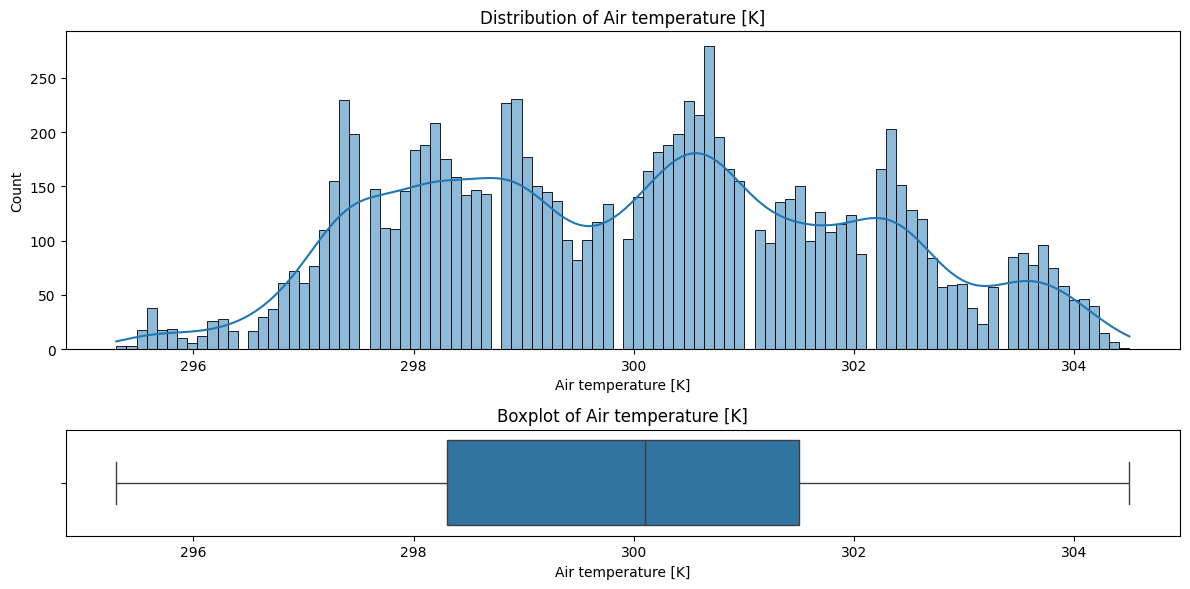

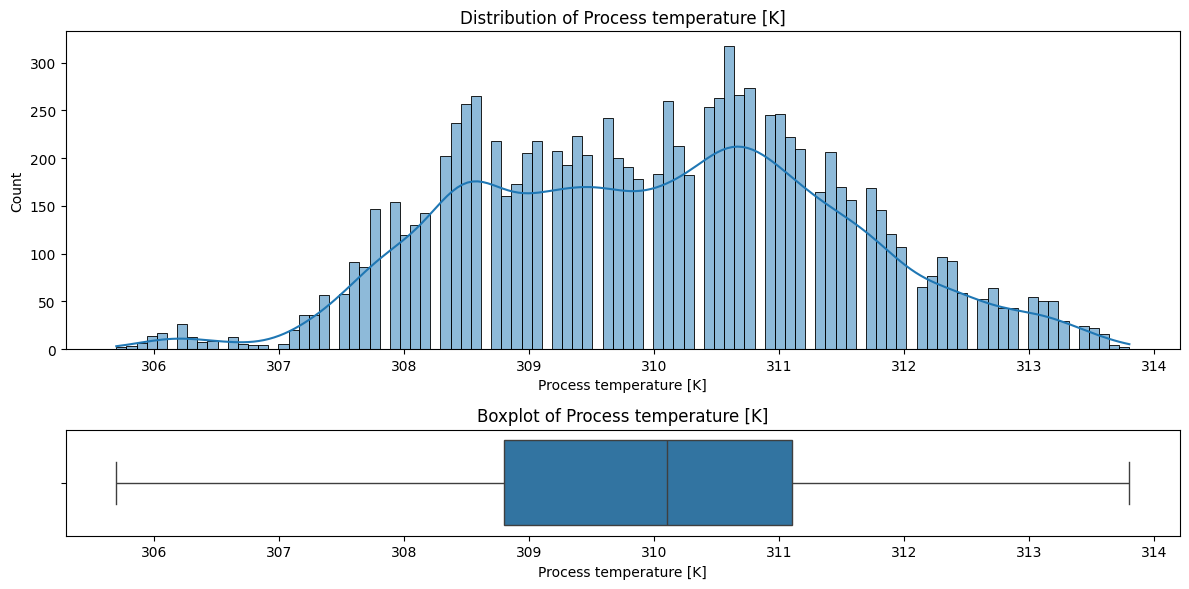

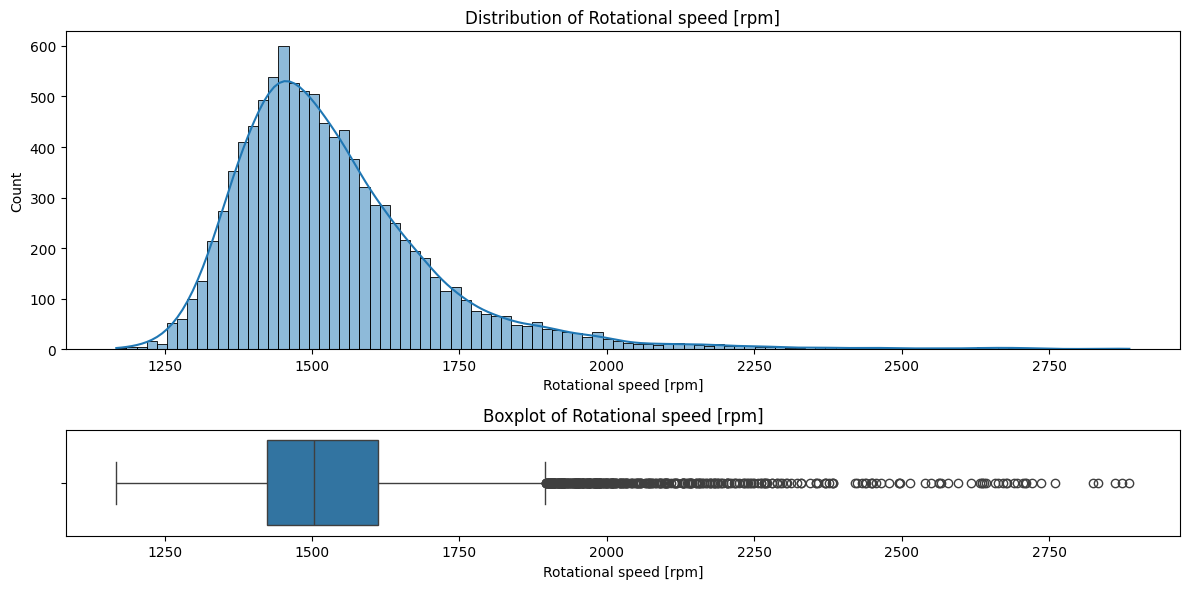

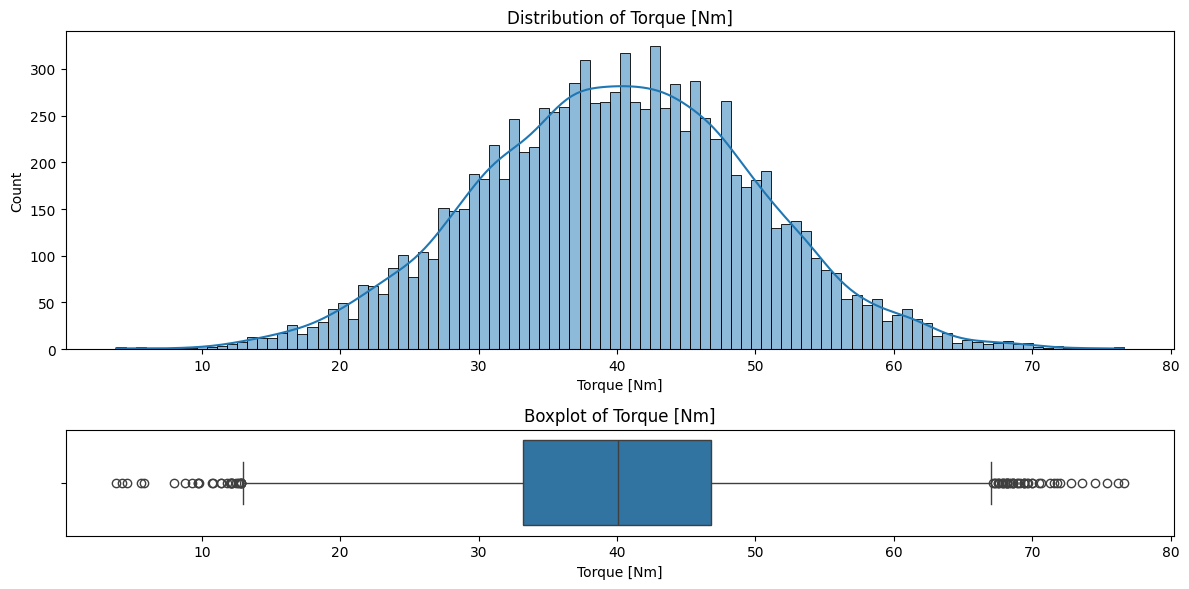

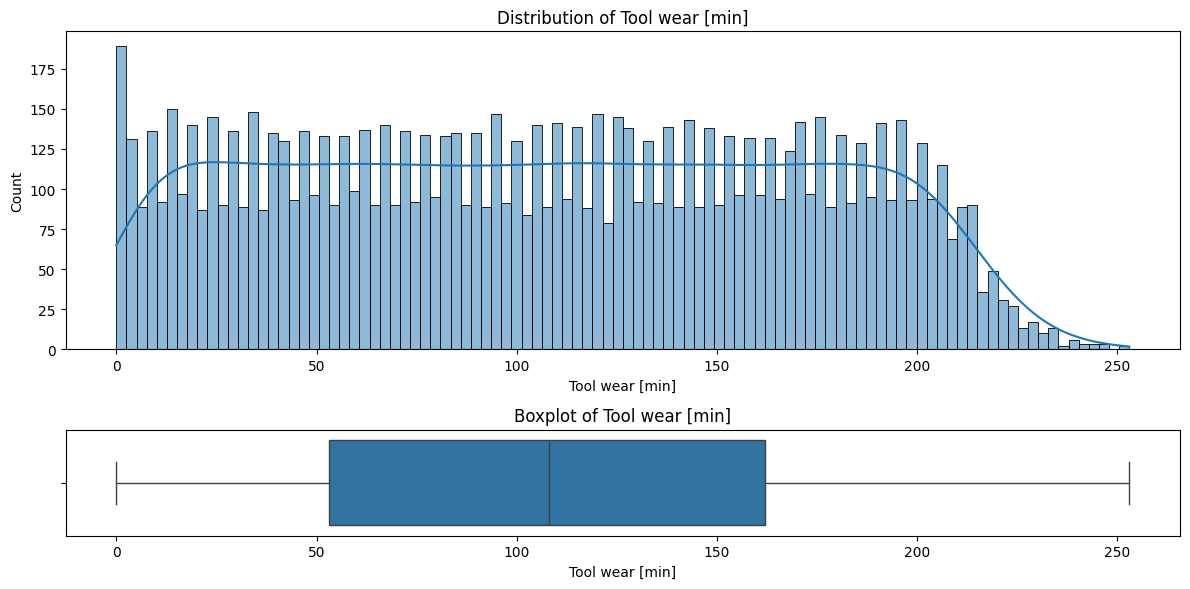

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in pm1_numeric.columns:
    fig, axes = plt.subplots(
        2, 1, 
        figsize=(12, 6), 
        gridspec_kw={'height_ratios': [3, 1]}  # histogram bigger than boxplot
    )

    # Histogram + KDE (Top)
    sns.histplot(pm1_numeric[col], kde=True, bins=100, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')

    # Boxplot (Bottom)
    sns.boxplot(x=pm1_numeric[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

In [90]:
pm1_categorical = pm1.select_dtypes(include=['object'])
pm1_categorical= pm1_categorical.drop(['Product ID'], axis=1)
pm1_categorical = pm1_categorical[pm1_categorical['Failure Type'] != 'No Failure']
pm1_categorical.columns

/var/folders/64/9w08f9mx7jz8k04fw5jhrc1w0000gn/T/ipykernel_63209/2005805364.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  pm1_categorical = pm1.select_dtypes(include=['object'])


Index(['Type', 'Failure Type'], dtype='str')

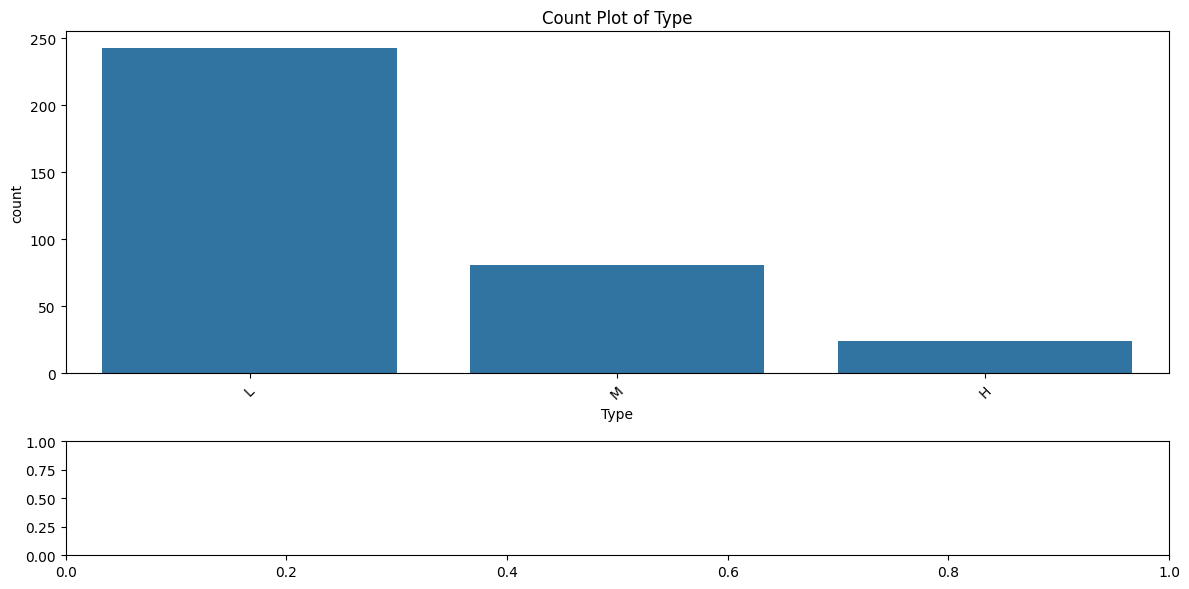

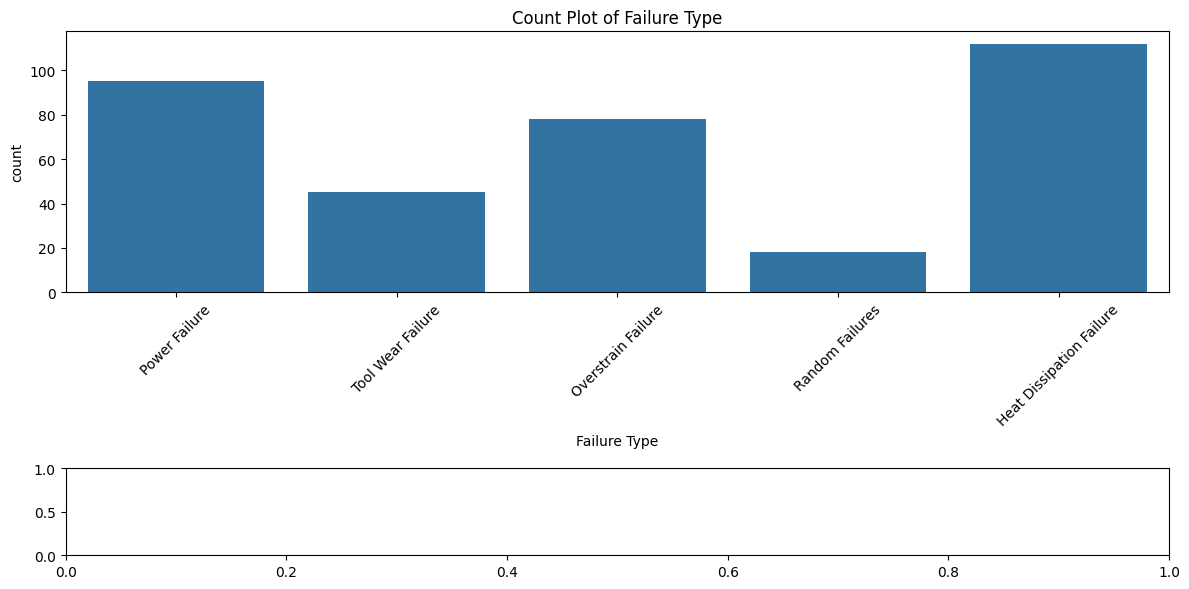

In [97]:

for col in pm1_categorical.columns:
    fig, axes = plt.subplots(
        2, 1,
        figsize=(12, 6),
        gridspec_kw={'height_ratios': [3, 1]}
    )

    # Count Plot (Top)
    sns.countplot(x=pm1_categorical[col], ax=axes[0])
    axes[0].set_title(f'Count Plot of {col}')
    axes[0].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

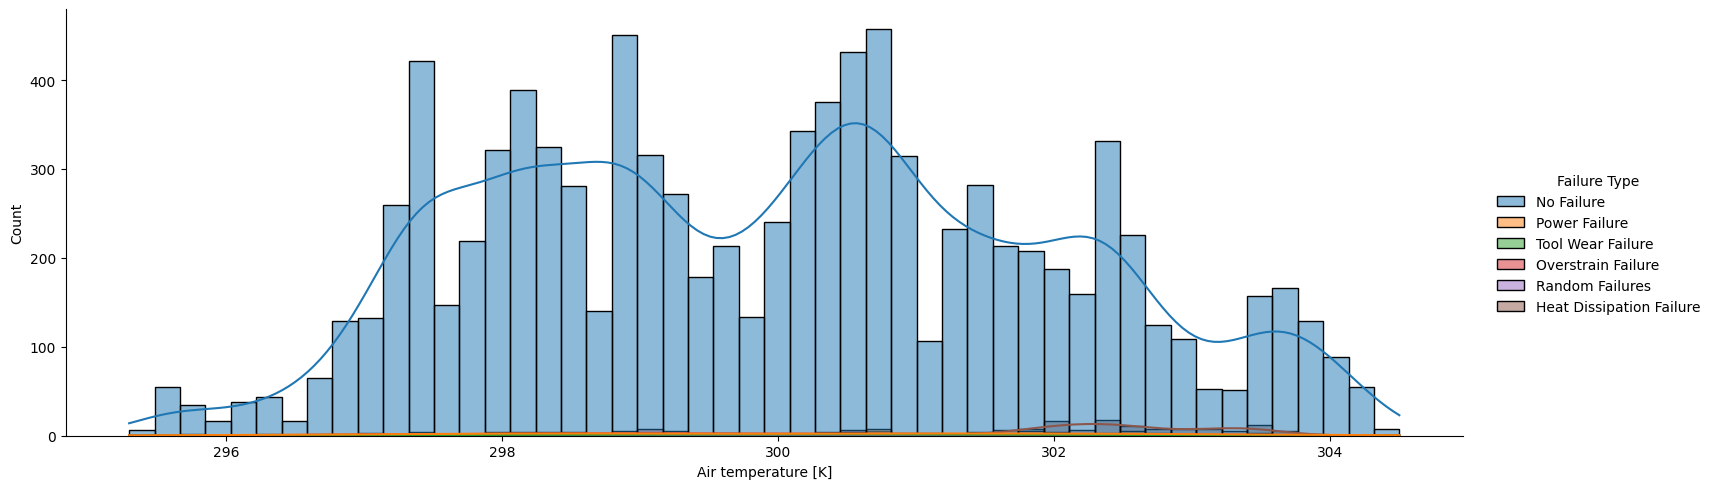

In [101]:
sns.displot(
    data=pm1,
    x="Air temperature [K]",
    hue="Failure Type",   # <-- color by failure category
    kde=True,
    bins=50,
    height=5,
    aspect=3
)

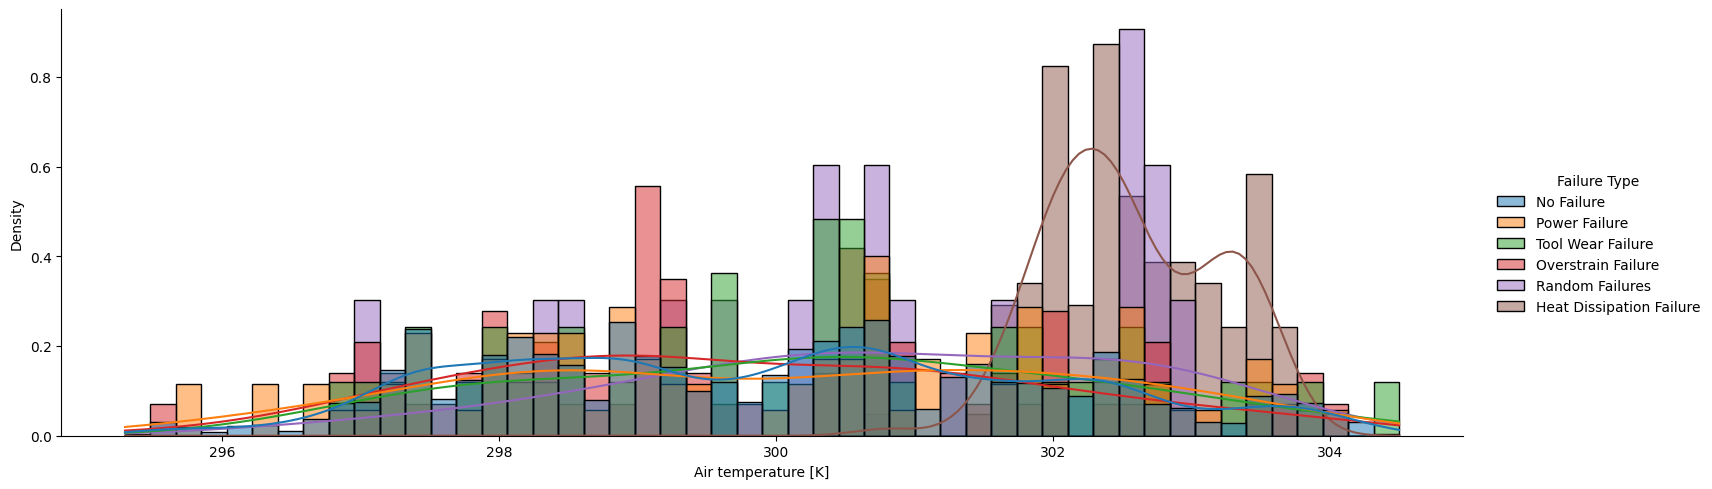

In [102]:
sns.displot(
    data=pm1,
    x="Air temperature [K]",
    hue="Failure Type",
    kde=True,
    bins=50,
    stat="density",        # normalize
    common_norm=False,     # <-- key line
    height=5,
    aspect=3
)

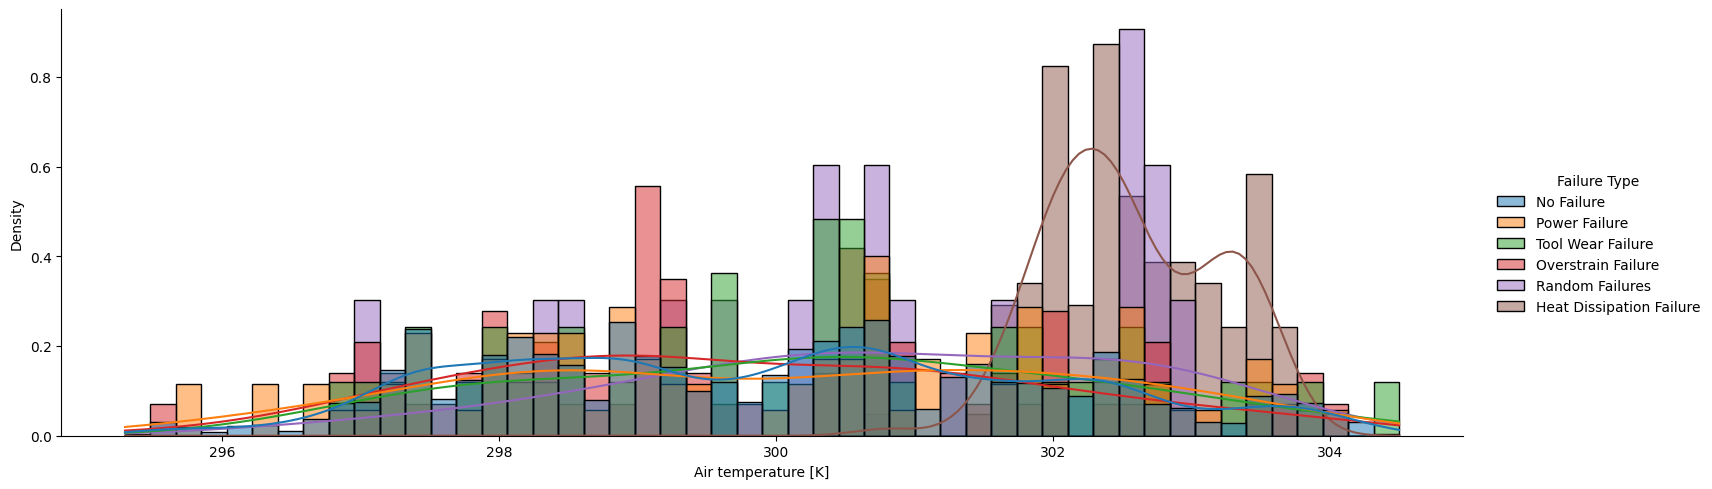

In [103]:
sns.displot(
    data=pm1,
    x="Air temperature [K]",
    hue="Failure Type",
    kde=True,
    bins=50,
    stat="density",        # normalize
    common_norm=False,     # <-- key line
    height=5,
    aspect=3
)

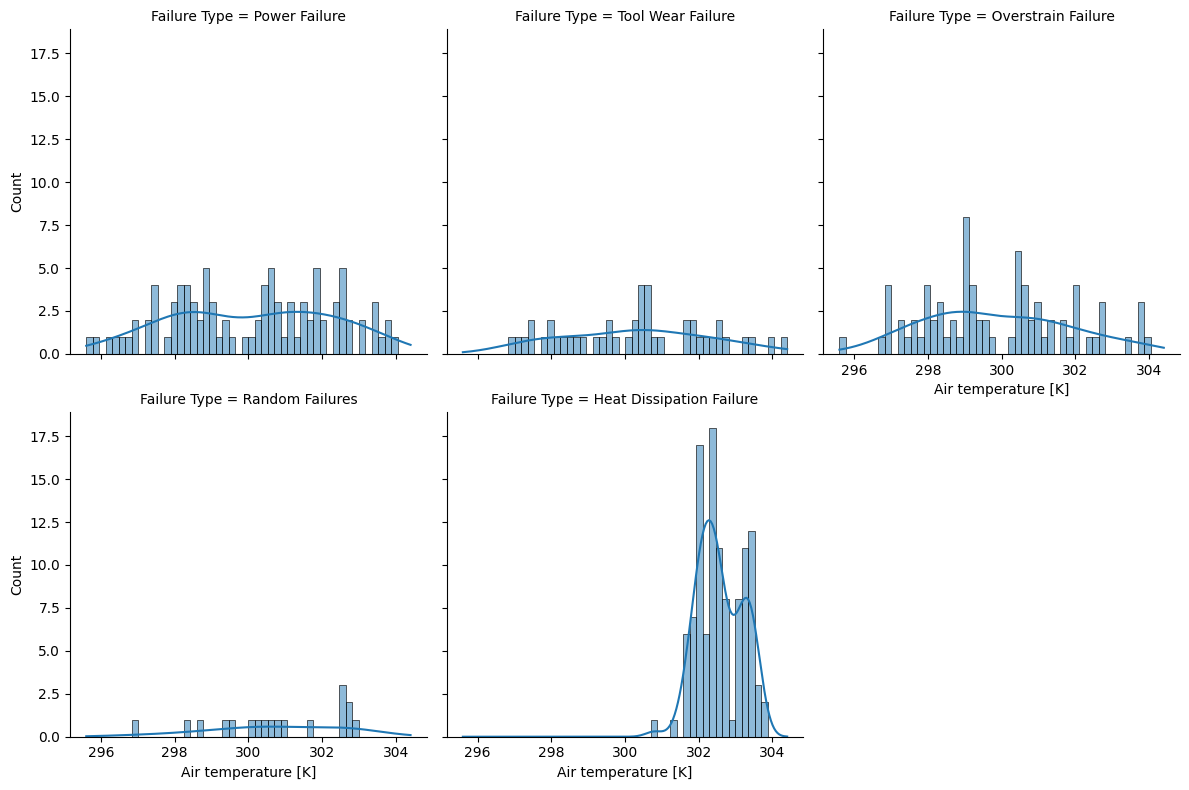

In [ ]:
pm1_fail = pm1[pm1["Failure Type"] != "No Failure"]

sns.displot(
    data=pm1_fail,
    x="Air temperature [K]",
    col="Failure Type",
    col_wrap=3,
    kde=True,
    bins=50,
    height=4
)

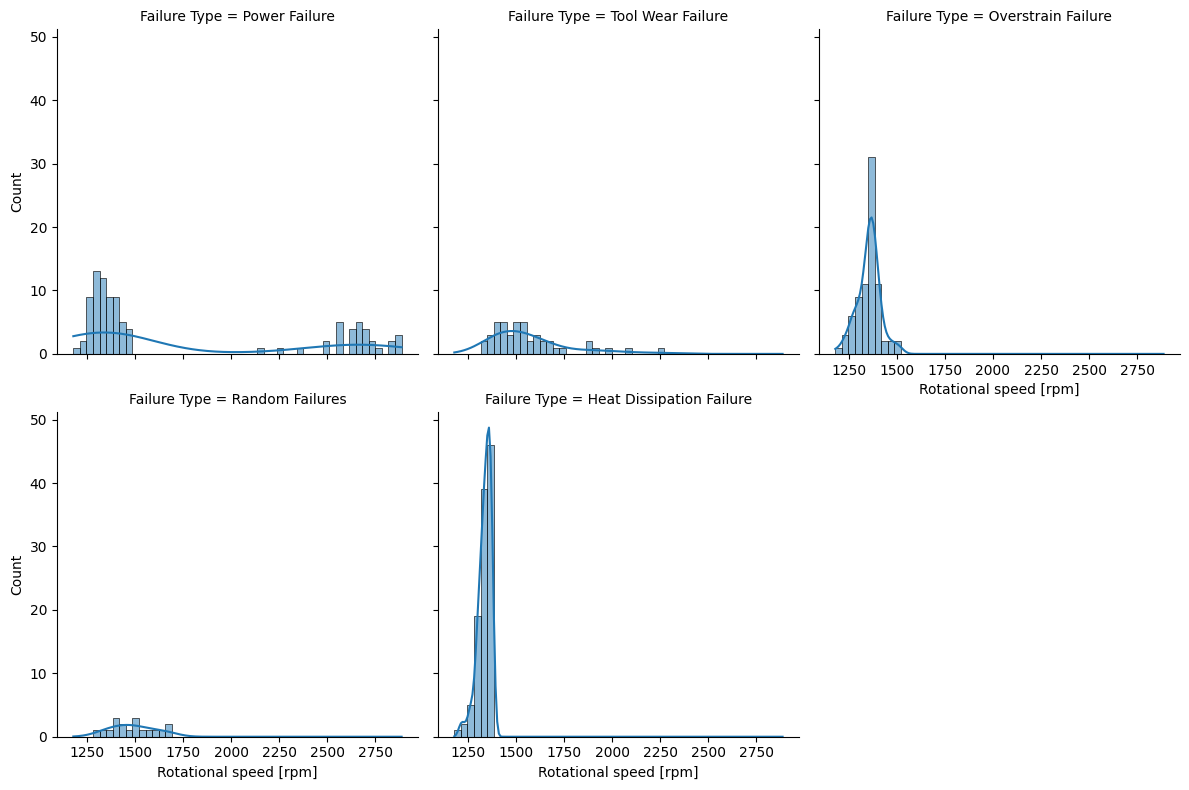

In [111]:
pm1_fail = pm1[pm1["Failure Type"] != "No Failure"]

sns.displot(
    data=pm1_fail,
    x="Rotational speed [rpm]",
    col="Failure Type",
    col_wrap=3,
    kde=True,
    bins=50,
    height=4
)

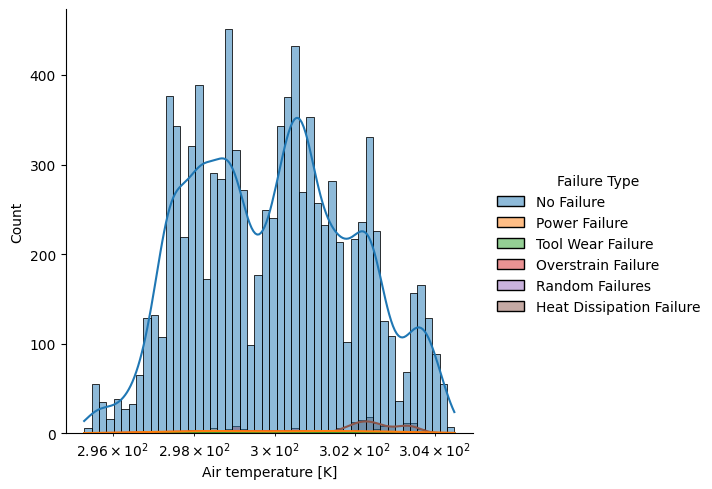

In [105]:
sns.displot(
    data=pm1,
    x="Air temperature [K]",
    hue="Failure Type",
    kde=True,
    bins=50,
    log_scale=True
)

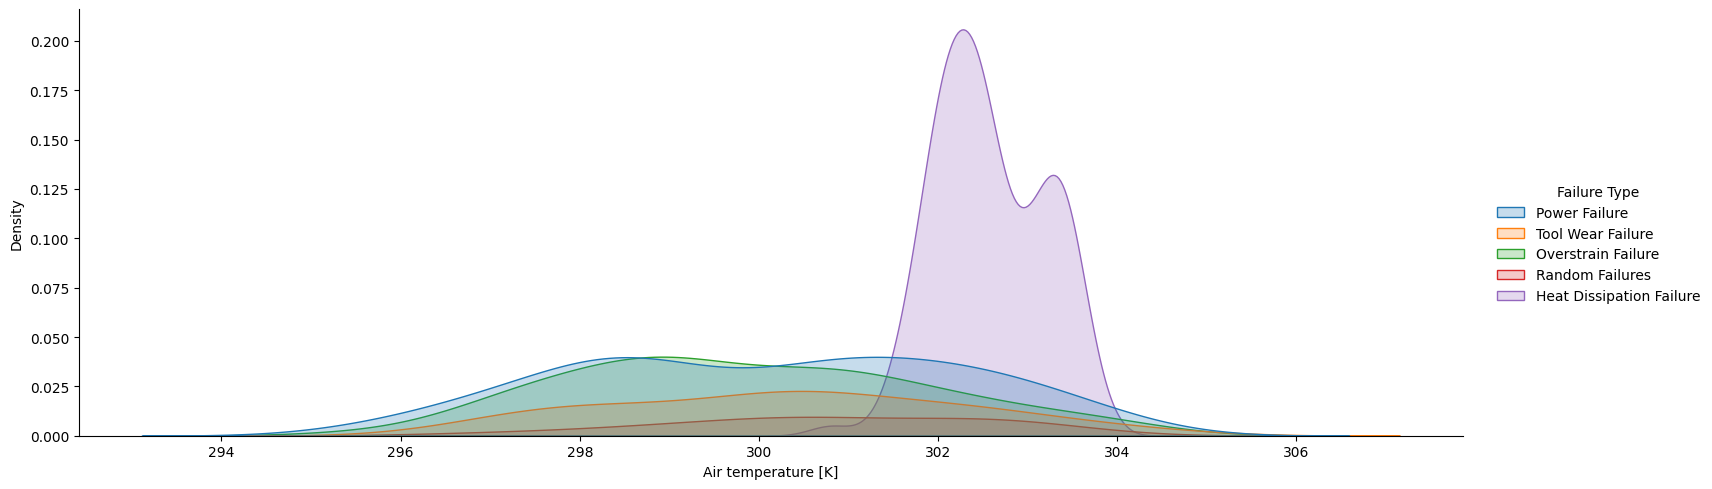

In [ ]:
pm1_fail = pm1[pm1["Failure Type"] != "No Failure"]
sns.displot(
    data=pm1_fail,
    x="Air temperature [K]",
    hue="Failure Type",
    kind="kde",          # <-- key change
    fill=True,
    height=5,
    aspect=3
)

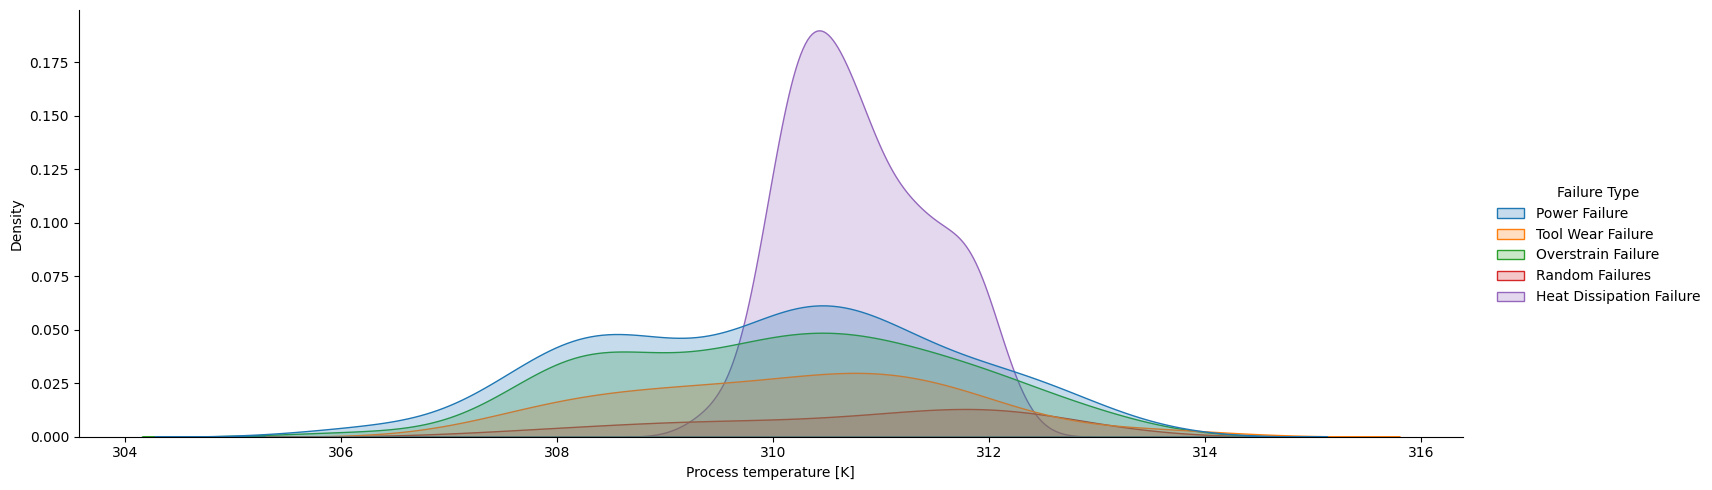

In [112]:
pm1_fail = pm1[pm1["Failure Type"] != "No Failure"]
sns.displot(
    data=pm1_fail,
    x="Process temperature [K]",
    hue="Failure Type",
    kind="kde",          # <-- key change
    fill=True,
    height=5,
    aspect=3
)

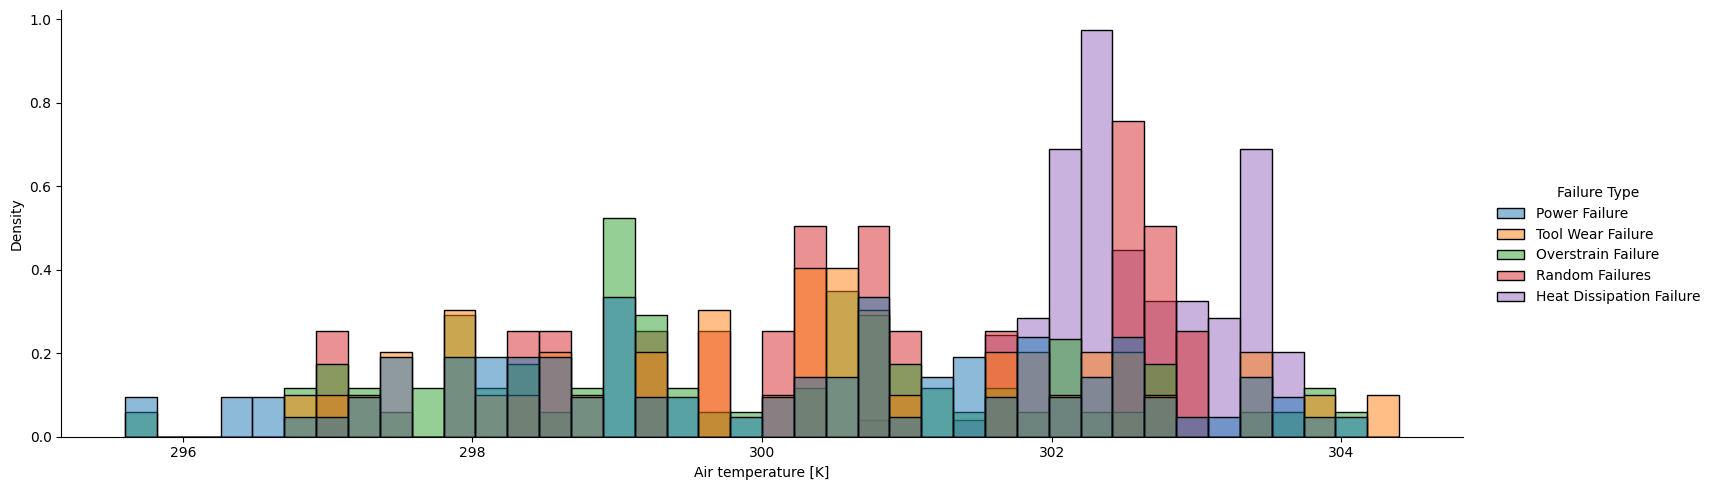

In [107]:
sns.displot(
    data=pm1_fail,
    x="Air temperature [K]",
    hue="Failure Type",
    bins=40,
    stat="density",
    common_norm=False,
    height=5,
    aspect=3
)

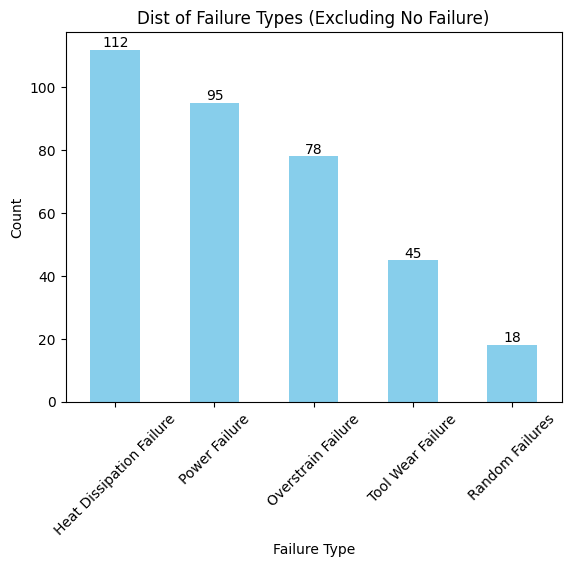

In [74]:
failure_type_counts = pm1['Failure Type'].value_counts()
failure_type_counts.drop('No Failure', inplace=True)  
failure_type_counts.plot(kind='bar', color='skyblue')
plt.title('Dist of Failure Types (Excluding No Failure)')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
for index, value in enumerate(failure_type_counts):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.show()

In [ ]:
#pm1.rename(columns={"Air temperature [K]": "air temp", "Process temperature [K]": "process temp", "Rotational speed [rpm]": "rpm", "Torque [Nm]": "torque", "Tool wear [min]": "wear/min"}, inplace=True)

In [23]:
for i in range(pm1.shape[0]):
    pm1['air temp'].iloc[i] = (pm1['air temp'].iloc[i] - 32) * 5.0/9.0
    pm1['process temp'].iloc[i] = (pm1['process temp'].iloc[i] - 32) * 5.0/9.0

/var/folders/64/9w08f9mx7jz8k04fw5jhrc1w0000gn/T/ipykernel_63209/2788030841.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  pm1['air temp'].iloc[i] = (pm1['air temp'].iloc[i] - 32) * 5.0/9.0
/var/folders/64/9w08f9mx7jz8k04fw5jhrc1w0000gn/T/ipykernel_63209/2788030841.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate

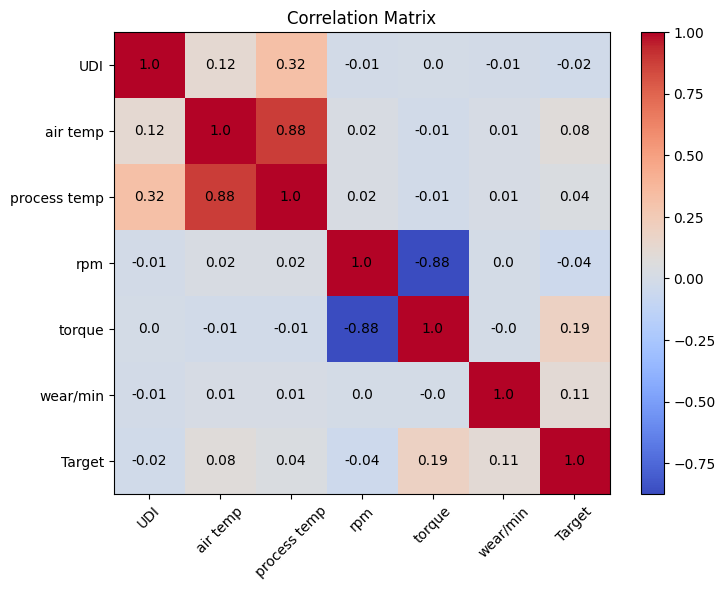

In [ ]:
pm1_numeric = pm1.select_dtypes(include=[np.number])  # Select only numeric columns for correlation analysis
correlation_matrix = pm1_numeric.corr()
# Create the heatmap with Matplotlib
plt.figure(figsize=(8, 6))  # Set the figure size
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none', aspect='auto')  # Display the correlation matrix as a heatmap
plt.colorbar()  # Add a colorbar to show the scale of correlation values

# Set axis labels
plt.xticks(np.arange(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)  # X-axis labels with 45-degree rotation
plt.yticks(np.arange(len(correlation_matrix.columns)), correlation_matrix.columns)  # Y-axis labels

# Annotate the heatmap with correlation values
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(j, i, round(correlation_matrix.iloc[i, j], 2), ha='center', va='center', color='black')  # Display correlation values

# Add a title to the plot
plt.title('Correlation Matrix')

# Save the figure to a file

# Display the heatmap
plt.show()  # Render and show the plot

In [28]:
pm1_dropped=pm1.drop(['process temp', 'torque'], axis=1)
pm1_dropped.columns

Index(['UDI', 'Product ID', 'Type', 'air temp', 'rpm', 'wear/min', 'Target',
       'Failure Type'],
      dtype='str')

In [29]:
pm1_dropped['Target'].value_counts()

Target
0    9661
1     339
Name: count, dtype: int64